<a href="https://colab.research.google.com/github/bttbtheelia/Work-GoldYahooFinance/blob/main/GoldYahooFinance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

OUTPUT 1: MODEL ARCHITECTURE COMPARISON

Training LSTM Model...

Training RNN Model...

Training GRU Model...

--- MODEL PERFORMANCE COMPARISON ---
      MAE ($)  RMSE ($)  Dir Accuracy (%)
LSTM     5.71      7.16             48.38
RNN      4.81      6.29             47.40
GRU      3.17      4.09             47.08

How to Interpret Result (Dir Accuracy)
<50%:Frequently mispredict price direction
50% - 52%:Random noise / 1-step lag persistence
53% - 60%+:Profitable prediction


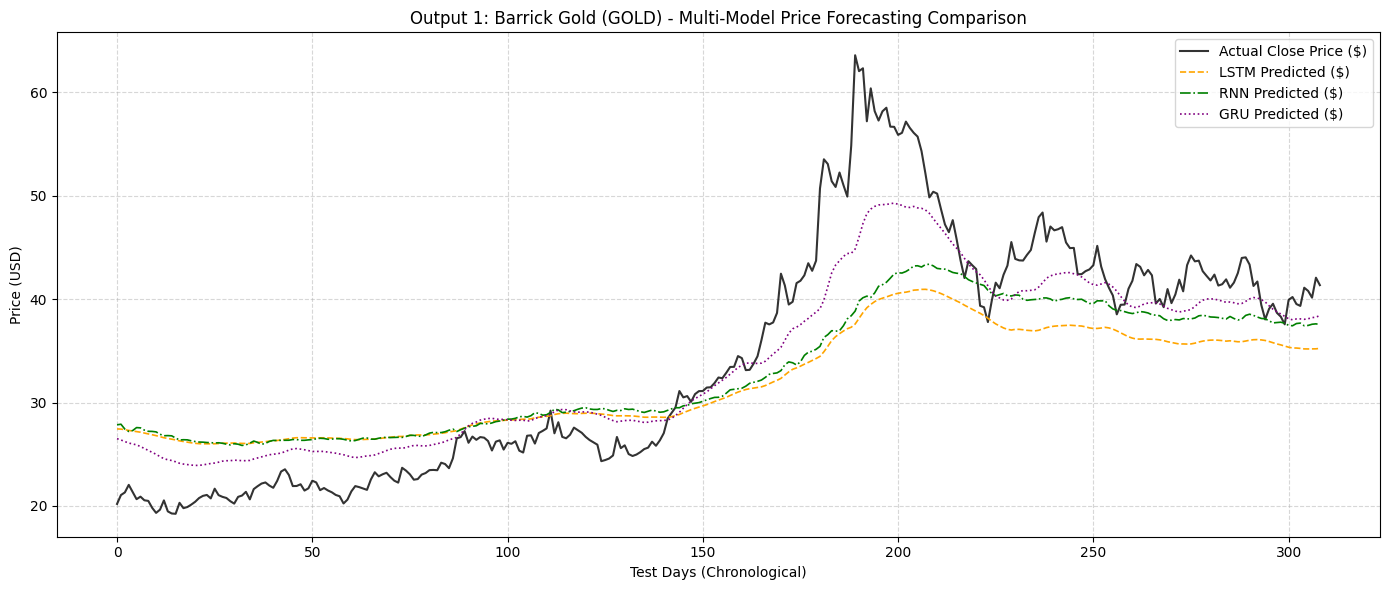


OUTPUT 2: INPUT FORECASTING (CLOSE, OPEN, HIGH, LOW, VOLUME)

--- PREVIEW OF INPUT FEATURES ---
                           Close   Open    High     Low  Volume
Date                                                           
2026-07-27 00:00:00-04:00  41.11  39.79  41.260  39.513  304800
2026-07-28 00:00:00-04:00  40.80  41.00  41.000  39.750  332800
2026-07-29 00:00:00-04:00  40.15  40.45  41.042  39.280  295500
2026-07-30 00:00:00-04:00  42.08  40.56  42.220  40.560  430300
2026-07-31 00:00:00-04:00  41.36  41.63  41.950  40.270  333900


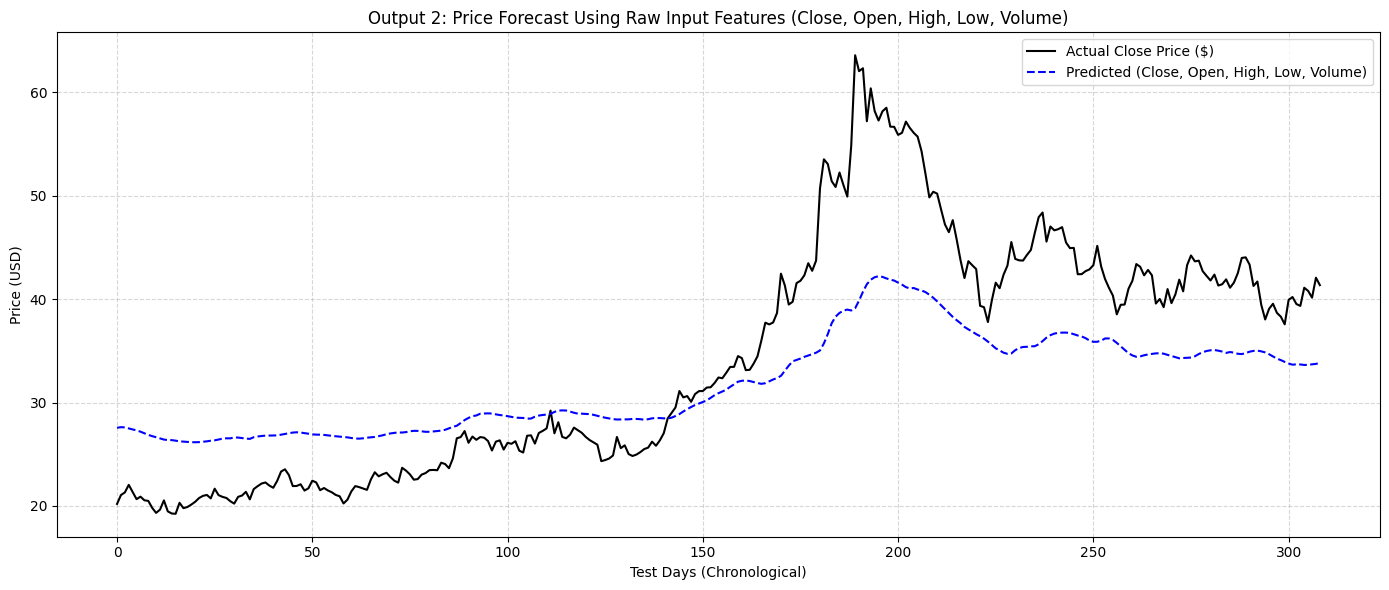


OUTPUT 3: TECHNICAL INDICATORS ANALYSIS & FORECASTING (MA, EMA, BB, MACD)

--- PREVIEW OF CALCULATED TECHNICAL INDICATORS ---
                             MA_20    MA_50   EMA_20    MACD  BB_Upper  BB_Lower
Date                                                                            
2026-07-27 00:00:00-04:00  40.5225  41.1268  40.2738 -0.5982   44.3751   36.6699
2026-07-28 00:00:00-04:00  40.5070  41.1357  40.3239 -0.4839   44.3521   36.6619
2026-07-29 00:00:00-04:00  40.4340  41.1680  40.3073 -0.4407   44.2463   36.6217
2026-07-30 00:00:00-04:00  40.4115  41.2204  40.4761 -0.2479   44.1767   36.6463
2026-07-31 00:00:00-04:00  40.2800  41.2580  40.5603 -0.1514   43.6855   36.8745


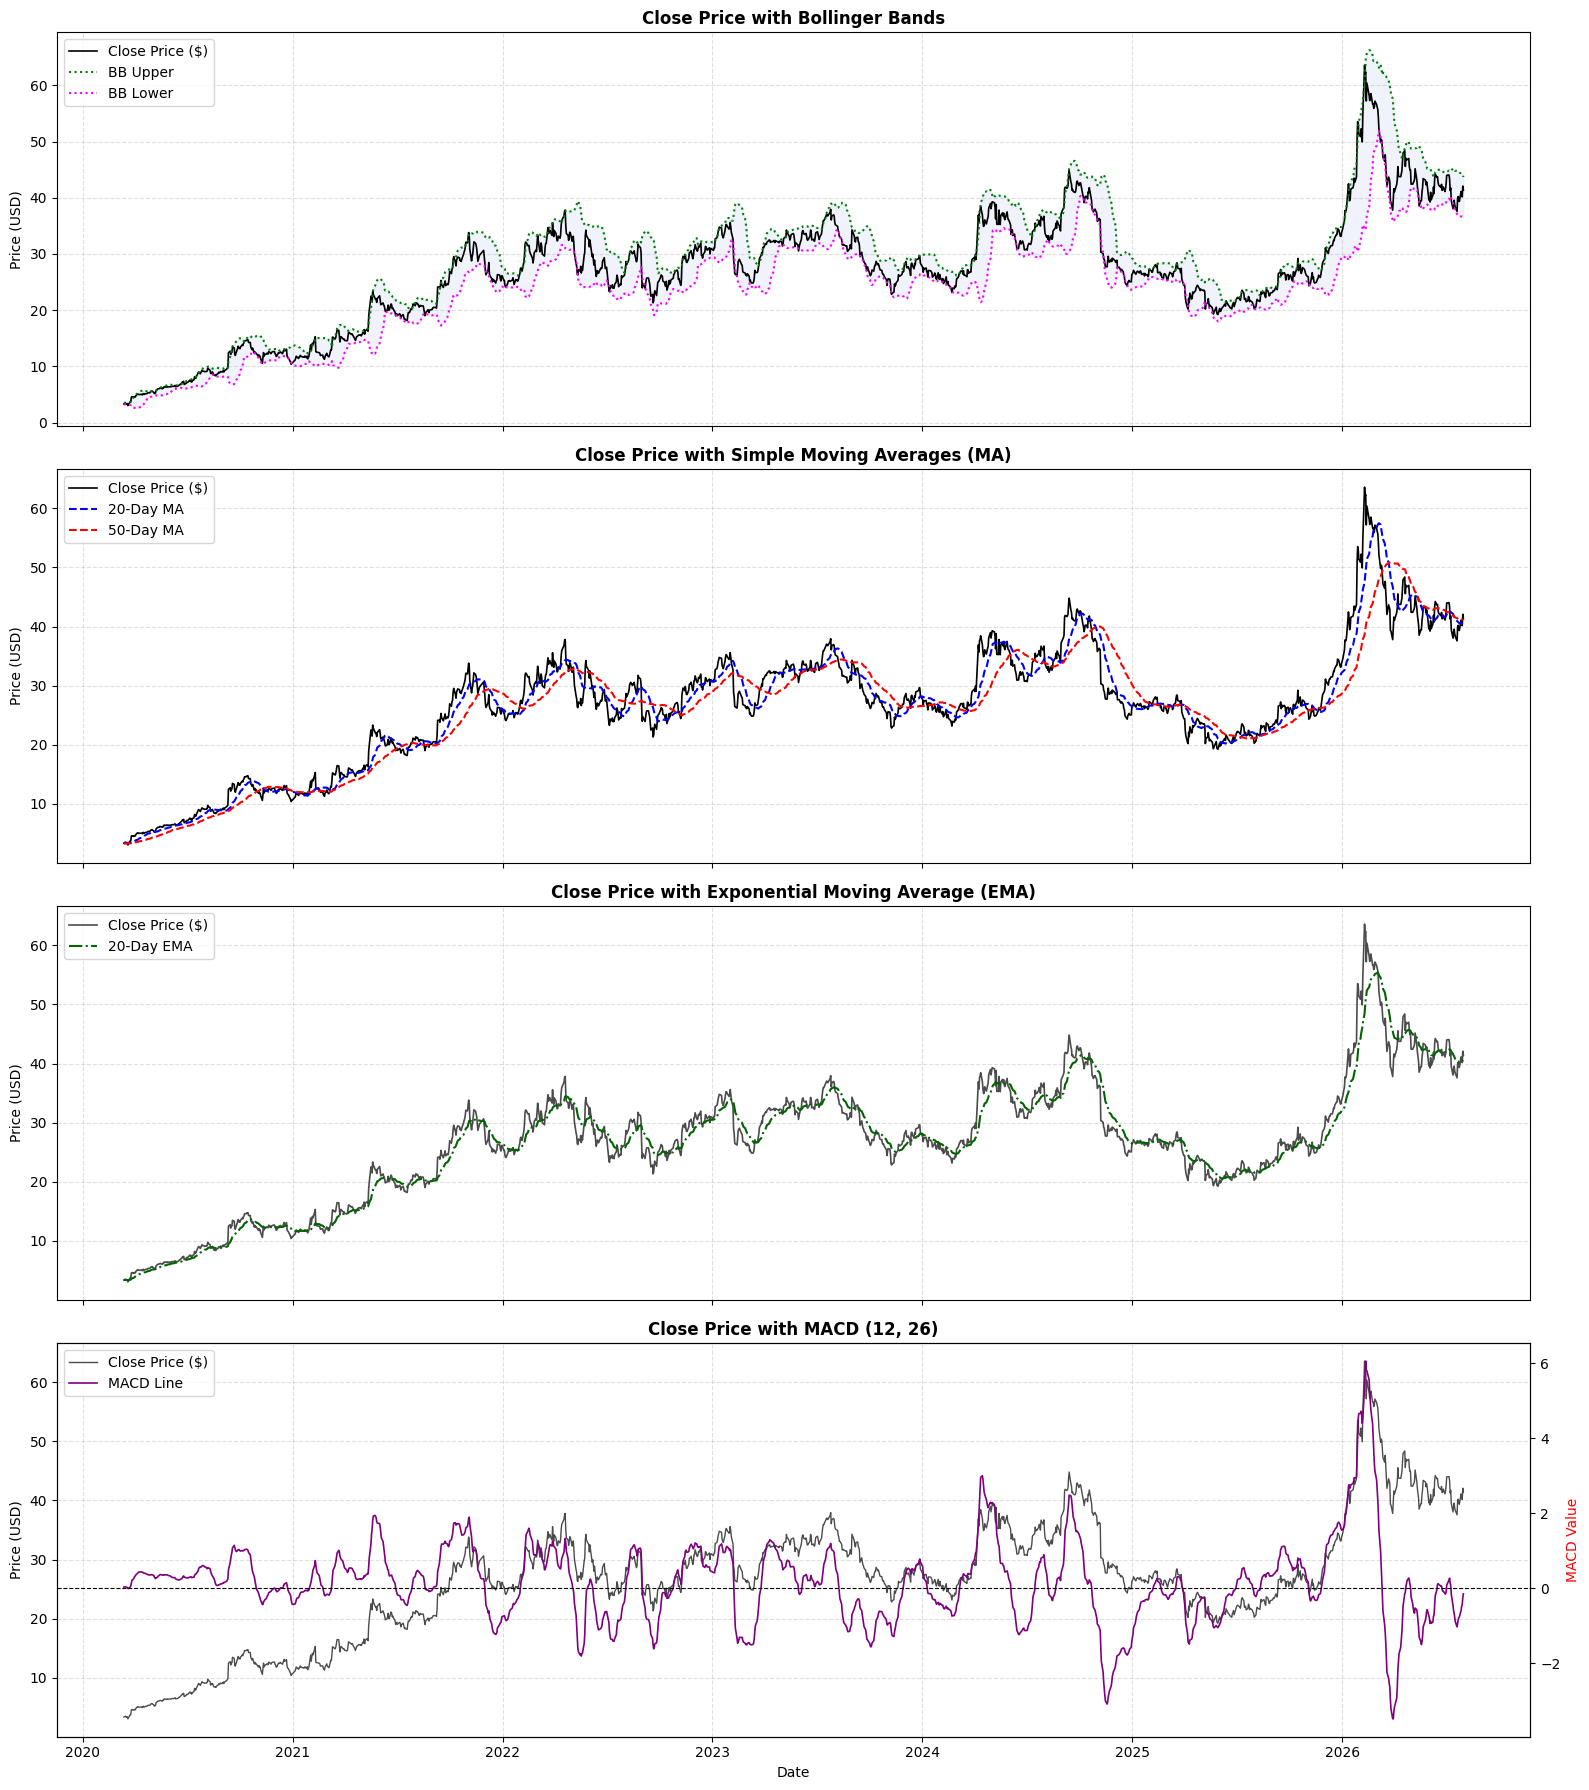

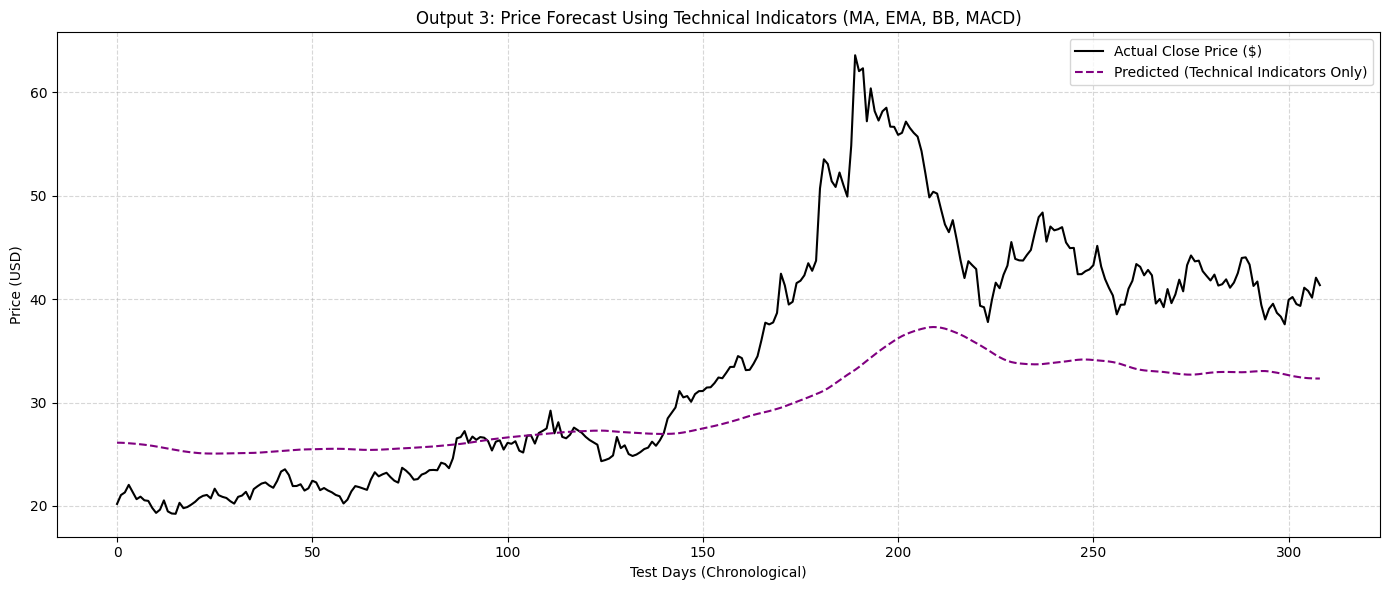

In [6]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler

# ---------------------------------------------------------
# GLOBAL DATA LOADING & PREPARATION
# ---------------------------------------------------------
df = yf.Ticker('GOLD').history(start='2020-01-01', end='2026-08-01')

# Calculate Technical Indicators
df['MA_20'] = df['Close'].rolling(window=20).mean()
df['MA_50'] = df['Close'].rolling(window=50).mean()
df['EMA_20'] = df['Close'].ewm(span=20, adjust=False).mean()

exp1 = df['Close'].ewm(span=12, adjust=False).mean()
exp2 = df['Close'].ewm(span=26, adjust=False).mean()
df['MACD'] = exp1 - exp2

df['BB_Middle'] = df['Close'].rolling(window=20).mean()
std = df['Close'].rolling(window=20).std()
df['BB_Upper'] = df['BB_Middle'] + (2 * std)
df['BB_Lower'] = df['BB_Middle'] - (2 * std)

df = df.dropna()

LOOKBACK = 60

# ---------------------------------------------------------
# EXPLICIT MODEL DEFINITIONS
# ---------------------------------------------------------
class MultivariateLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_dim, hidden_size=hidden_dim,
                            num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])  # Pass final time-step output to linear layer
        return out

class MultivariateRNN(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2):
        super().__init__()
        self.rnn = nn.RNN(input_size=input_dim, hidden_size=hidden_dim,
                          num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :])
        return out

class MultivariateGRU(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2):
        super().__init__()
        self.gru = nn.GRU(input_size=input_dim, hidden_size=hidden_dim,
                          num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        out = self.fc(out[:, -1, :])
        return out

def prepare_tensors(feature_matrix, target_matrix, lookback=60):
    X, y = [], []
    for i in range(len(feature_matrix) - lookback):
        X.append(feature_matrix[i : i + lookback])
        y.append(target_matrix[i + lookback])
    X, y = np.array(X), np.array(y)
    train_size = int(len(X) * 0.8)

    X_tr = torch.tensor(X[:train_size], dtype=torch.float32)
    y_tr = torch.tensor(y[:train_size], dtype=torch.float32).unsqueeze(1)
    X_te = torch.tensor(X[train_size:], dtype=torch.float32)
    y_te = y[train_size:]
    return X_tr, y_tr, X_te, y_te

# ---------------------------------------------------------
# OUTPUT 1: MODEL COMPARISON (LSTM vs RNN vs GRU)
# ---------------------------------------------------------
print("=========================================================================================")
print("OUTPUT 1: MODEL ARCHITECTURE COMPARISON")
print("=========================================================================================")

all_feature_cols = ['Close', 'Open', 'High', 'Low', 'Volume', 'MA_20', 'MA_50', 'EMA_20', 'MACD', 'BB_Upper', 'BB_Lower']

scaler_all = MinMaxScaler(feature_range=(0, 1))
scaled_all = scaler_all.fit_transform(df[all_feature_cols].values)

price_scaler = MinMaxScaler(feature_range=(0, 1))
price_scaler.fit(df[['Close']].values)

X_tr_all, y_tr_all, X_te_all, y_te_all = prepare_tensors(scaled_all, scaled_all[:, 0], LOOKBACK)

input_dim_all = len(all_feature_cols)

models = {
    'LSTM': MultivariateLSTM(input_dim=input_dim_all),
    'RNN':  MultivariateRNN(input_dim=input_dim_all),
    'GRU':  MultivariateGRU(input_dim=input_dim_all)
}

predictions_dict = {}
metrics_dict = {}
EPOCHS = 35

for name, model_inst in models.items():
    print(f"\nTraining {name} Model...")
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model_inst.parameters(), lr=0.001)

    for epoch in range(EPOCHS):
        model_inst.train()
        optimizer.zero_grad()
        loss = criterion(model_inst(X_tr_all), y_tr_all)
        loss.backward()
        optimizer.step()

    model_inst.eval()
    with torch.no_grad():
        raw_preds = model_inst(X_te_all).numpy()

    pred_usd = price_scaler.inverse_transform(raw_preds)
    predictions_dict[name] = pred_usd

    actual_usd = price_scaler.inverse_transform(y_te_all.reshape(-1, 1))
    mae = np.mean(np.abs(actual_usd - pred_usd))
    rmse = np.sqrt(np.mean((actual_usd - pred_usd) ** 2))
    actual_diff = np.diff(actual_usd, axis=0)
    pred_diff = np.diff(pred_usd, axis=0)
    dir_acc = np.mean(np.sign(actual_diff) == np.sign(pred_diff)) * 100
    metrics_dict[name] = {
        'MAE ($)': round(mae, 2),
        'RMSE ($)': round(rmse, 2),
        'Dir Accuracy (%)': round(dir_acc, 2)
    }

metrics_df = pd.DataFrame(metrics_dict).T
print("\n--- MODEL PERFORMANCE COMPARISON ---")
print(metrics_df)

print('\n\033[1m'+"How to Interpret Result (Dir Accuracy)"+'\033[0m')
print('\033[1m'+"<50%:"+'\033[0m'+ "Frequently mispredict price direction")
print('\033[1m'+"50% - 52%:"+'\033[0m' +"Random noise / 1-step lag persistence")
print('\033[1m'+"53% - 60%+:"+'\033[0m'+ "Profitable prediction")

plt.figure(figsize=(14, 6))
plt.plot(actual_usd, label='Actual Close Price ($)', color='black', linewidth=1.5, alpha=0.8)
colors = {'LSTM': 'orange', 'RNN': 'green', 'GRU': 'purple'}
styles = {'LSTM': '--', 'RNN': '-.', 'GRU': ':'}

for name, preds in predictions_dict.items():
    plt.plot(preds, label=f'{name} Predicted ($)', color=colors[name], linestyle=styles[name], linewidth=1.2)

plt.title('Output 1: Barrick Gold (GOLD) - Multi-Model Price Forecasting Comparison')
plt.xlabel('Test Days (Chronological)')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# OUTPUT 2: INPUT FORECASTING (Close, Open, High, Low, Volume)
# ---------------------------------------------------------
print("\n=========================================================================================")
print("OUTPUT 2: INPUT FORECASTING (CLOSE, OPEN, HIGH, LOW, VOLUME)")
print("=========================================================================================")

input_cols = ['Close', 'Open', 'High', 'Low', 'Volume']

print("\n--- PREVIEW OF INPUT FEATURES ---")
print(df[input_cols].tail(5).round(4).to_string())

scaler_input = MinMaxScaler(feature_range=(0, 1))
scaled_inputs = scaler_input.fit_transform(df[input_cols].values)

X_tr_in, y_tr_in, X_te_in, y_te_in = prepare_tensors(scaled_inputs, scaled_inputs[:, 0], LOOKBACK)

model_input = MultivariateLSTM(input_dim=len(input_cols))
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_input.parameters(), lr=0.001)

for epoch in range(EPOCHS):
    model_input.train()
    optimizer.zero_grad()
    loss = criterion(model_input(X_tr_in), y_tr_in)
    loss.backward()
    optimizer.step()

model_input.eval()
with torch.no_grad():
    raw_preds_in = model_input(X_te_in).numpy()

pred_usd_in = price_scaler.inverse_transform(raw_preds_in)
actual_usd_in = price_scaler.inverse_transform(y_te_in.reshape(-1, 1))

plt.figure(figsize=(14, 6))
plt.plot(actual_usd_in, label='Actual Close Price ($)', color='black', linewidth=1.5)
plt.plot(pred_usd_in, label='Predicted (Close, Open, High, Low, Volume)', color='blue', linestyle='--')
plt.title('Output 2: Price Forecast Using Raw Input Features (Close, Open, High, Low, Volume)')
plt.xlabel('Test Days (Chronological)')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# OUTPUT 3: TECHNICAL INDICATORS (MA, EMA, BB, MACD)
# ---------------------------------------------------------
print("\n=========================================================================================")
print("OUTPUT 3: TECHNICAL INDICATORS ANALYSIS & FORECASTING (MA, EMA, BB, MACD)")
print("=========================================================================================")

indicator_cols = ['MA_20', 'MA_50', 'EMA_20', 'MACD', 'BB_Upper', 'BB_Lower']

print("\n--- PREVIEW OF CALCULATED TECHNICAL INDICATORS ---")
print(df[indicator_cols].tail(5).round(4).to_string())

# Technical Indicator Visualizations
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(16, 18), sharex=True)

# 1. Bollinger Bands
ax1.plot(df.index, df['Close'], label='Close Price ($)', color='black', linewidth=1.2)
ax1.plot(df.index, df['BB_Upper'], label='BB Upper', color='green', linestyle=':')
ax1.plot(df.index, df['BB_Lower'], label='BB Lower', color='magenta', linestyle=':')
ax1.fill_between(df.index, df['BB_Lower'], df['BB_Upper'], color='royalblue', alpha=0.08)
ax1.set_title('Close Price with Bollinger Bands', fontweight='bold')
ax1.set_ylabel('Price (USD)')
ax1.legend(loc='upper left')
ax1.grid(True, linestyle='--', alpha=0.4)

# 2. Moving Averages
ax2.plot(df.index, df['Close'], label='Close Price ($)', color='black', linewidth=1.2)
ax2.plot(df.index, df['MA_20'], label='20-Day MA', color='blue', linestyle='--')
ax2.plot(df.index, df['MA_50'], label='50-Day MA', color='red', linestyle='--')
ax2.set_title('Close Price with Simple Moving Averages (MA)', fontweight='bold')
ax2.set_ylabel('Price (USD)')
ax2.legend(loc='upper left')
ax2.grid(True, linestyle='--', alpha=0.4)

# 3. EMA
ax3.plot(df.index, df['Close'], label='Close Price ($)', color='black', alpha=0.7, linewidth=1.2)
ax3.plot(df.index, df['EMA_20'], label='20-Day EMA', color='darkgreen', linestyle='-.')
ax3.set_title('Close Price with Exponential Moving Average (EMA)', fontweight='bold')
ax3.set_ylabel('Price (USD)')
ax3.legend(loc='upper left')
ax3.grid(True, linestyle='--', alpha=0.4)

# 4. MACD
ax4.plot(df.index, df['Close'], label='Close Price ($)', color='black', alpha=0.7, linewidth=1)
ax4.set_ylabel('Price (USD)')
ax4.set_title('Close Price with MACD (12, 26)', fontweight='bold')
ax4.set_xlabel('Date')
ax4.grid(True, linestyle='--', alpha=0.4)

ax_macd = ax4.twinx()
ax_macd.plot(df.index, df['MACD'], label='MACD Line', color='purple', linewidth=1.2)
ax_macd.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax_macd.set_ylabel('MACD Value', color='red')

lines1, labels1 = ax4.get_legend_handles_labels()
lines2, labels2 = ax_macd.get_legend_handles_labels()
ax4.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

# Forecast Using Technical Indicators Only
scaler_ind = MinMaxScaler(feature_range=(0, 1))
scaled_ind = scaler_ind.fit_transform(df[indicator_cols].values)

target_scaled = price_scaler.transform(df[['Close']].values).flatten()

X_tr_ind, y_tr_ind, X_te_ind, y_te_ind = prepare_tensors(scaled_ind, target_scaled, LOOKBACK)

model_ind = MultivariateLSTM(input_dim=len(indicator_cols))
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_ind.parameters(), lr=0.001)

for epoch in range(EPOCHS):
    model_ind.train()
    optimizer.zero_grad()
    loss = criterion(model_ind(X_tr_ind), y_tr_ind)
    loss.backward()
    optimizer.step()

model_ind.eval()
with torch.no_grad():
    raw_preds_ind = model_ind(X_te_ind).numpy()

pred_usd_ind = price_scaler.inverse_transform(raw_preds_ind)
actual_usd_ind = price_scaler.inverse_transform(y_te_ind.reshape(-1, 1))

plt.figure(figsize=(14, 6))
plt.plot(actual_usd_ind, label='Actual Close Price ($)', color='black', linewidth=1.5)
plt.plot(pred_usd_ind, label='Predicted (Technical Indicators Only)', color='purple', linestyle='--')
plt.title('Output 3: Price Forecast Using Technical Indicators (MA, EMA, BB, MACD)')
plt.xlabel('Test Days (Chronological)')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()